--- Starting Feature Engineering: Agri Sentiment ---
Shifting weekend news to the next available Monday...
Reindexing to a continuous daily calendar and filling sparse gaps...
Applying psychological decay (EMA) to historical sentiment...
Generating diagnostic graphs...


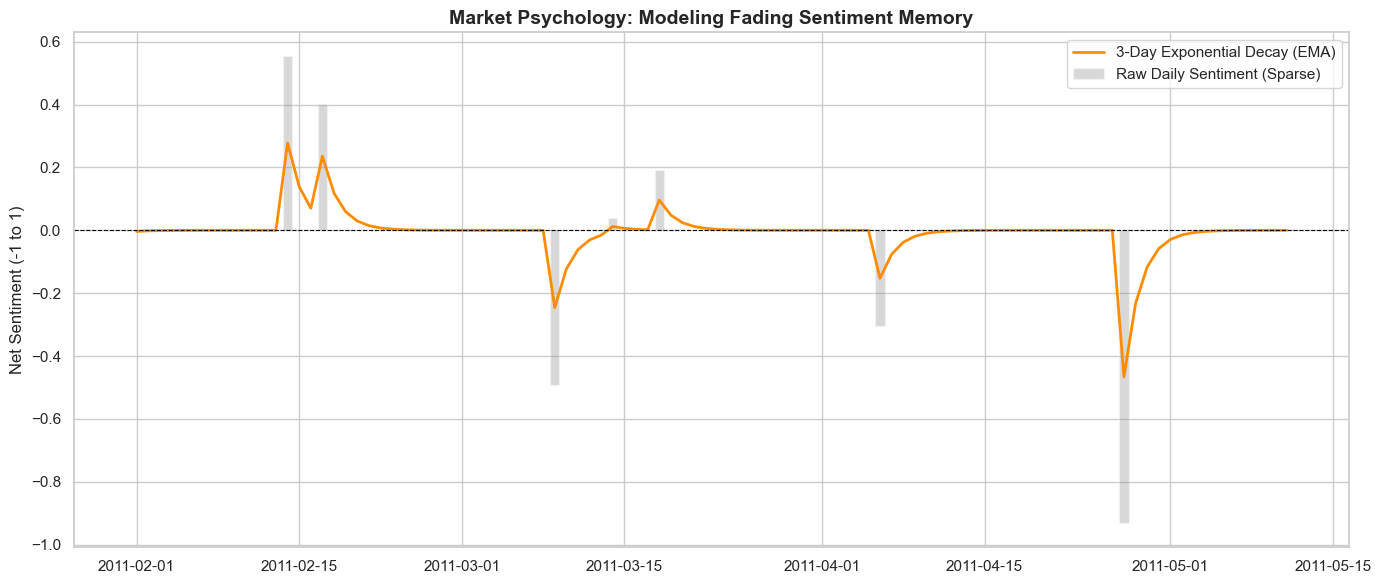


Success! Semi-cleaned sentiment dataset saved to: D:\MS_Data_Science_Thesis\Data_Cleaning\Semi_Clean_Datasets\agri_sentiment_engineered_II.csv
        Date  Net_Sentiment  Sentiment_EMA_3d  Sentiment_EMA_7d
0 2010-04-07      -0.020754         -0.020754         -0.020754
1 2010-04-08       0.000000         -0.010377         -0.015565
2 2010-04-09       0.000000         -0.005188         -0.011674
3 2010-04-10       0.000000         -0.002594         -0.008756
4 2010-04-11       0.000000         -0.001297         -0.006567
5 2010-04-12       0.000000         -0.000649         -0.004925
6 2010-04-13       0.000000         -0.000324         -0.003694
7 2010-04-14       0.000000         -0.000162         -0.002770
8 2010-04-15       0.000000         -0.000081         -0.002078
9 2010-04-16       0.000000         -0.000041         -0.001558


In [5]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Directory Setup
base_dir = r"D:\MS_Data_Science_Thesis"
raw_folder = os.path.join(base_dir, r"Data_Extraction\Raw_Data_Folder")
clean_folder = os.path.join(base_dir, r"Data_Cleaning\Semi_Clean_Datasets")

os.makedirs(clean_folder, exist_ok=True)

# Pointing to the file you downloaded from Google Colab
input_file = os.path.join(raw_folder, "cotton_finbert_daily_scores.csv")

def engineer_sentiment_features():
    print("--- Starting Feature Engineering: Agri Sentiment ---")
    
    if not os.path.exists(input_file):
        print(f"Error: Could not find {input_file}")
        return

    # 2. Load Data
    df = pd.read_csv(input_file)
    df['Date'] = pd.to_datetime(df['Date'])
    
    # 3. Handle Weekend News (Shift to Monday)
    print("Shifting weekend news to the next available Monday...")
    # .dt.dayofweek: Monday=0, Sunday=6
    # If Saturday (5), add 2 days. If Sunday (6), add 1 day.
    df['Date'] = np.where(df['Date'].dt.dayofweek == 5, df['Date'] + pd.Timedelta(days=2), df['Date'])
    df['Date'] = np.where(df['Date'].dt.dayofweek == 6, df['Date'] + pd.Timedelta(days=1), df['Date'])
    
    # Because multiple weekend articles might now land on the same Monday, we must group and average again
    df = df.groupby('Date')[['FinBERT_Positive', 'FinBERT_Negative', 'FinBERT_Neutral', 'Net_Sentiment']].mean().reset_index()
    
    # 4. Handle Sparsity (Create a continuous daily calendar)
    print("Reindexing to a continuous daily calendar and filling sparse gaps...")
    full_date_range = pd.date_range(start=df['Date'].min(), end=df['Date'].max(), freq='D')
    df_continuous = df.set_index('Date').reindex(full_date_range).rename_axis('Date').reset_index()
    
    # Fill missing days (No news = Neutral)
    df_continuous['FinBERT_Positive'] = df_continuous['FinBERT_Positive'].fillna(0)
    df_continuous['FinBERT_Negative'] = df_continuous['FinBERT_Negative'].fillna(0)
    df_continuous['FinBERT_Neutral'] = df_continuous['FinBERT_Neutral'].fillna(1) # 100% Neutral
    df_continuous['Net_Sentiment'] = df_continuous['Net_Sentiment'].fillna(0)
    
    # 5. The Decay Factor (Exponential Moving Average)
    print("Applying psychological decay (EMA) to historical sentiment...")
    # span=3 means the "memory" of the news has a rough half-life of 3 days
    df_continuous['Sentiment_EMA_3d'] = df_continuous['Net_Sentiment'].ewm(span=3, adjust=False).mean()
    df_continuous['Sentiment_EMA_7d'] = df_continuous['Net_Sentiment'].ewm(span=7, adjust=False).mean()
    
    # 6. Data Visualization
    # Let's visualize a 3-month slice to see the decay in action
    print("Generating diagnostic graphs...")
    sample_slice = df_continuous.iloc[300:400] # Grabbing a random 100-day window
    
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(14, 6))
    
    # Plot the raw, sparse spikes
    plt.bar(sample_slice['Date'], sample_slice['Net_Sentiment'], color='gray', alpha=0.3, label='Raw Daily Sentiment (Sparse)')
    
    # Plot the decayed memory
    plt.plot(sample_slice['Date'], sample_slice['Sentiment_EMA_3d'], color='darkorange', linewidth=2, label='3-Day Exponential Decay (EMA)')
    
    plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
    plt.title('Market Psychology: Modeling Fading Sentiment Memory', fontsize=14, fontweight='bold')
    plt.ylabel('Net Sentiment (-1 to 1)', fontsize=12)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # 7. Export the intermediate dataset
    output_path = os.path.join(clean_folder, "agri_sentiment_engineered_II.csv")
    df_continuous.to_csv(output_path, index=False)
    
    print(f"\nSuccess! Semi-cleaned sentiment dataset saved to: {output_path}")
    print(df_continuous[['Date', 'Net_Sentiment', 'Sentiment_EMA_3d', 'Sentiment_EMA_7d']].head(10))

if __name__ == "__main__":
    engineer_sentiment_features()